# Heat Equation on a Metric Graph (Edges of Length L)

In `heat_equation_graph.ipynb`, the graph Laplacian treats each edge as a simple link between two nodes. All the heat sits at the nodes. Edges only say which nodes connect — they have no length.

 Each edge is now an **interval of length `L`**. Heat spreads continuously along the edge, not just between its endpoints in one step. This makes the problem a heat equation on a **metric graph** (also called a quantum graph):
- On each edge: $u_t = u_{xx}$.
- At each vertex: **Kirchhoff conditions** hold — $u$ is continuous, and the outgoing derivatives sum to zero (flux is conserved).



## Setup

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

## Graph

A small graph with 5 nodes: a 5-cycle plus one extra edge (0–2). This gives nodes 0 and 2 degree 3. At these two vertices, the Kirchhoff condition must balance flux from three edges, not two.

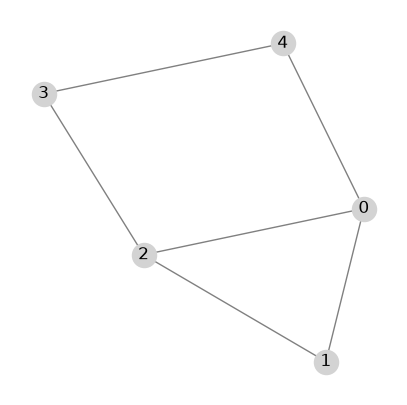

In [2]:
G = nx.Graph()
G.add_nodes_from(range(5))
G.add_edges_from([(0, 1), (1, 2), (2, 3), (3, 4), (4, 0), (0, 2)])
pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(5, 5))
nx.draw(G, pos, ax=ax, node_color="lightgray", edge_color="gray", with_labels=True)
plt.show()

## Metric Discretization

Each edge is now the interval $[0, L]$. We split it into `N` interior grid points, spaced $h = L / (N + 1)$ apart, between the two vertex endpoints. A vertex is shared by all edges that meet there. This gives it one value of $u$, which enforces continuity at junctions.

We build the discrete operator with a finite-volume method. This makes flux conservation (the Kirchhoff condition) automatic — we do not need to add it by hand:
- Each pair of neighboring grid points on an edge gets conductance $1/h$. This adds to the stiffness matrix `K` (a weighted graph Laplacian).
- Each point gets a *mass* in `M`. Interior points get a full cell of width $h$. Each vertex gets half a cell ($h_e / 2$) from every edge that meets it.

The resulting system $M \dot u = -K u$ reduces to the plain graph heat equation from the original notebook when $L \to 0$ (or $N \to 0$).

In [3]:
n_nodes = G.number_of_nodes()
N = 20       # interior grid points per edge
L = 1.0      # length of every edge interval

edges = list(G.edges())
edge_info = {}
next_idx = n_nodes
for (i, j) in edges:
    h = L / (N + 1)
    idx = np.arange(next_idx, next_idx + N)
    edge_info[(i, j)] = {"h": h, "idx": idx}
    next_idx += N

n_total = next_idx  # vertices + all interior edge points
print(f"{n_nodes} vertices + {len(edges)} edges x {N} interior points = {n_total} unknowns")

5 vertices + 6 edges x 20 interior points = 125 unknowns


In [4]:
K = np.zeros((n_total, n_total))
M = np.zeros(n_total)

for (i, j), info in edge_info.items():
    h, idx = info["h"], info["idx"]
    chain = [i] + list(idx) + [j]  # vertex -> interior points -> vertex, in order along the edge
    for a, b in zip(chain[:-1], chain[1:]):
        g = 1.0 / h
        K[a, a] += g
        K[b, b] += g
        K[a, b] -= g
        K[b, a] -= g
    M[idx] += h
    M[i] += h / 2
    M[j] += h / 2

print("max |row sum of K| (should be ~0, i.e. flux-conservative):", np.abs(K.sum(axis=1)).max())

max |row sum of K| (should be ~0, i.e. flux-conservative): 0.0


## Initial Condition

Same as the original notebook: all heat starts at one vertex (node 0). Everywhere else is zero, including every point along each edge.

In [5]:
u0 = np.zeros(n_total)
u0[0] = 1.0

dt = 0.005
n_steps = 400

## Finite Difference Time-Stepping (Crank–Nicolson)

`M` is diagonal. We step the system $M \dot u = -Ku$ with the same Crank–Nicolson method as before, adjusted to include `M`:

$$\left(\tfrac{M}{\Delta t} + \tfrac{K}{2}\right) u^{n+1} = \left(\tfrac{M}{\Delta t} - \tfrac{K}{2}\right) u^n$$

The initial spike sits on a fine grid ($h \approx L/21$), which makes `K` stiff there. If we start with Crank–Nicolson on this sharp data, it rings: node 0 briefly overshoots, then dips below zero. This is not physical — diffusion cannot produce negative heat.

The standard fix is Rannacher smoothing: take a few backward-Euler steps first, then switch to Crank–Nicolson. Backward Euler is L-stable, so it damps the high-frequency ringing before the more accurate Crank–Nicolson steps take over.

In [6]:
n_startup = 4  # backward-Euler steps before switching to Crank-Nicolson

A_be = np.diag(M) / dt + K
A_cn = np.diag(M) / dt + 0.5 * K
B_cn = np.diag(M) / dt - 0.5 * K

history = np.zeros((n_steps + 1, n_total))
history[0] = u0

u = u0.copy()
for k in range(n_steps):
    if k < n_startup:
        u = np.linalg.solve(A_be, (M / dt) * u)
    else:
        u = np.linalg.solve(A_cn, B_cn @ u)
    history[k + 1] = u

print("total heat conserved:", M @ history[0], "->", M @ history[-1])
print("min value ever reached:", history.min())

total heat conserved: 0.07142857142857142 -> 0.07142857142856482
min value ever reached: 0.0


## Graph Snapshots Over Time

Each edge is a straight line between its two vertices, colored along its length by the field value. This shows heat spreading through the interval, not just jumping between endpoints. Vertices are drawn as circles on top, using the same color scale.

(The straight-line layout is only for drawing. It does not show the interval length `L` to scale — it is a schematic layout, like the spring layout used for the plain graph above.)

The initial spike (`u = 1` at one point) is over 30 times brighter than anything that follows. A linear color scale would make every later frame look black. Instead, we use a `PowerNorm` color scale. It is still one shared colorbar across all panels, just compressed so the later, smaller changes stay visible.

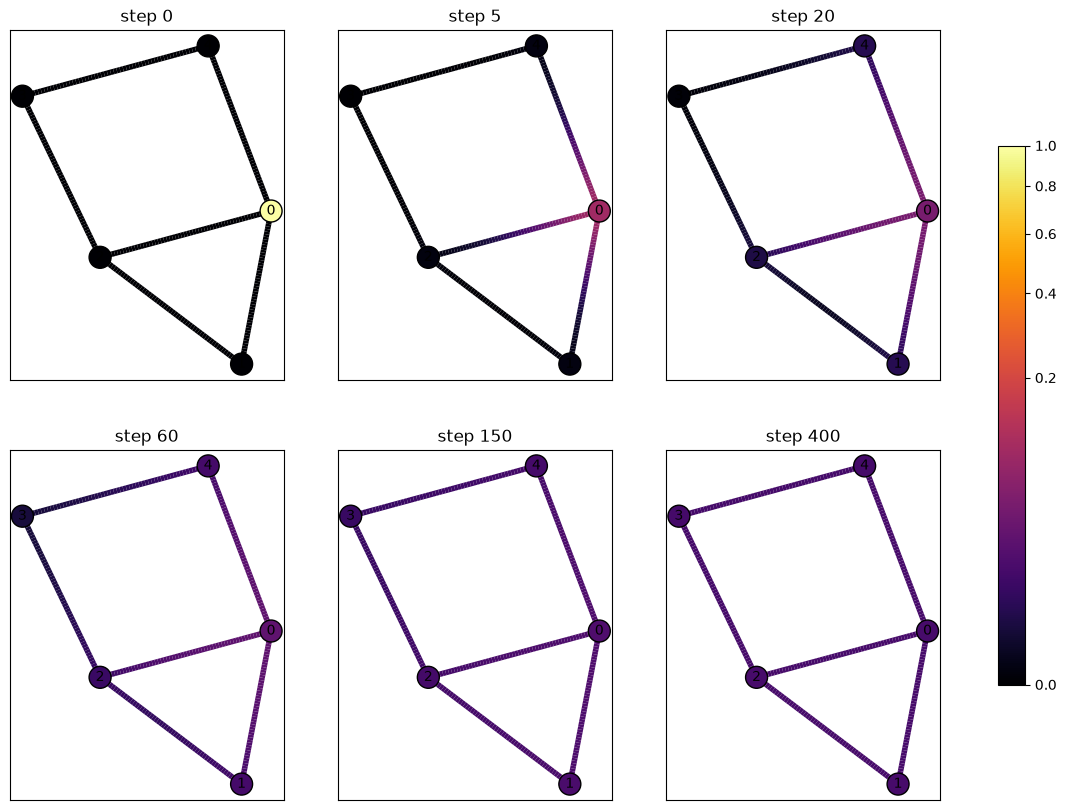

In [7]:
def edge_profile_points(i, j, info, n_line=60):
    """Positions of n_line points laid out along the straight segment from pos[i] to pos[j]."""
    t = np.linspace(0, 1, n_line)
    p0, p1 = np.array(pos[i]), np.array(pos[j])
    return p0[None, :] + t[:, None] * (p1 - p0)[None, :], t


def edge_values(i, j, info, u_state, t):
    """Interpolate u along the edge (vertex i) -> interior points -> (vertex j) at parametric t."""
    h = info["h"]
    grid_x = np.concatenate([[0.0], (np.arange(N) + 1) * h, [L]]) / L
    grid_u = np.concatenate([[u_state[i]], u_state[info["idx"]], [u_state[j]]])
    return np.interp(t, grid_x, grid_u)


def draw_snapshot(ax, step, norm, cmap="inferno"):
    u_state = history[step]
    for (i, j), info in edge_info.items():
        points, t = edge_profile_points(i, j, info)
        vals = edge_values(i, j, info, u_state, t)
        segments = np.stack([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=cmap, norm=norm)
        lc.set_array((vals[:-1] + vals[1:]) / 2)
        lc.set_linewidth(4)
        ax.add_collection(lc)
    node_xy = np.array([pos[n] for n in G.nodes()])
    ax.scatter(node_xy[:, 0], node_xy[:, 1], c=u_state[:n_nodes], cmap=cmap,
               norm=norm, s=250, edgecolors="black", zorder=3)
    for n, (x, y) in pos.items():
        ax.annotate(str(n), (x, y), ha="center", va="center", zorder=4)
    ax.set_title(f"step {step}")
    ax.set_xticks([]); ax.set_yticks([])
    ax.autoscale()


snapshot_steps = [0, 5, 20, 60, 150, 400]
norm = plt.matplotlib.colors.PowerNorm(gamma=0.35, vmin=history.min(), vmax=history.max())

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, step in zip(axes.flat, snapshot_steps):
    draw_snapshot(ax, step, norm)

sm = plt.cm.ScalarMappable(cmap="inferno", norm=norm)
fig.colorbar(sm, ax=axes, shrink=0.7)
plt.show()

## Heat Profile Along Individual Edges

This plot shows something the combinatorial graph model cannot: $u(x)$ inside a single edge, as a function of position $x \in [0, L]$, at several times. Edge (0, 1) is next to the initial pulse. Edge (2, 3) is two edges away, and only shows heat once it has had time to cross the graph.

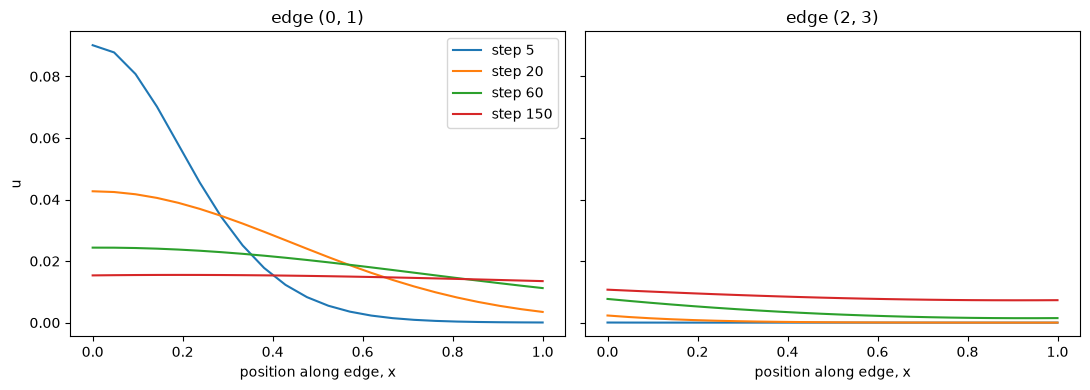

In [8]:
profile_steps = [5, 20, 60, 150]
show_edges = [(0, 1), (2, 3)]

fig, axes = plt.subplots(1, len(show_edges), figsize=(11, 4), sharey=True)
for ax, (i, j) in zip(axes, show_edges):
    info = edge_info[(i, j)]
    h = info["h"]
    x = np.concatenate([[0.0], (np.arange(N) + 1) * h, [L]])
    for step in profile_steps:
        u_state = history[step]
        u_edge = np.concatenate([[u_state[i]], u_state[info["idx"]], [u_state[j]]])
        ax.plot(x, u_edge, label=f"step {step}")
    ax.set_title(f"edge ({i}, {j})")
    ax.set_xlabel("position along edge, x")
axes[0].set_ylabel("u")
axes[0].legend()
plt.tight_layout()
plt.show()

## Vertex Values Over Time

This plot tracks the same 5 vertex values over time, for comparison with the original notebook. Here the values change more slowly at first. Heat must travel the length `L` of each interval before it reaches the next vertex, instead of diffusing there instantly.

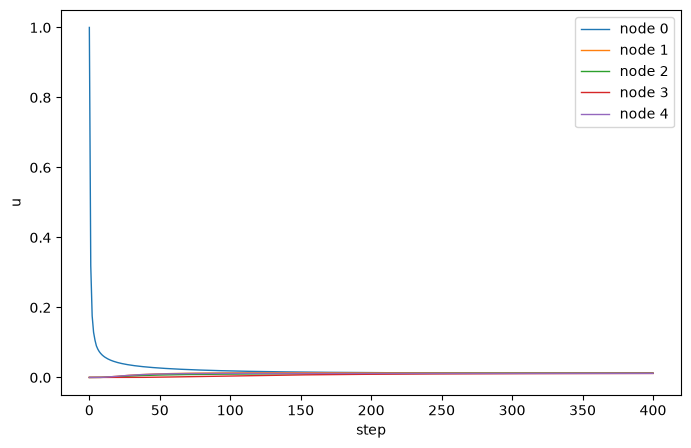

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for node in range(n_nodes):
    ax.plot(history[:, node], linewidth=1, label=f"node {node}")
ax.set_xlabel("step")
ax.set_ylabel("u")
ax.legend()
plt.show()